### Для большинства диагностик в пакете существуют методы, облегчающие работу с данными

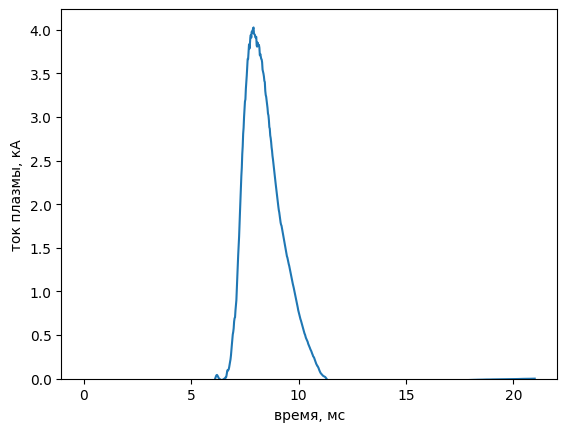

In [16]:
import mephistdatakit as mdk
import matplotlib.pyplot as plt

# Создаем объект клиентского приложения с токеном, указанным в файле config.yaml
client = mdk.Client()


shot = mdk.Shot(client.get_shot(3244))

time_Ip, current_Ip = shot.get_plasma_current()

plt.plot(time_Ip, current_Ip)
plt.xlabel("время, мс")
plt.ylabel("ток плазмы, кА")
plt.ylim(0,)
plt.show()


### Тем не менее, вы всегда можете обращаться к любой диагностике напрямую, путём парсинга hdf5 файла

### Вы можете узнать структуру файла следующим образом:

In [ ]:
print(shot.get_hdf5_structure())

├── META
│   └── Main
│       ├── Acknowledgements
│       ├── Description
│       ├── ID
│       └── Shot_time
├── Postprocess
│   ├── I_ind
│   │   ├── data
│   │   └── time
│   ├── I_pl
│   │   ├── data
│   │   └── time
│   └── tor_field
│       ├── data
│       └── time
├── PowSync
│   ├── HV
│   │   ├── HV:ch1
│   │   ├── HV:ch2
│   │   ├── HV:ch3
│   │   └── HV:ch4
│   ├── LV
│   │   ├── LV:ch1
│   │   ├── LV:ch2
│   │   ├── LV:ch3
│   │   └── LV:ch4
│   ├── sync_arduino
│   │   ├── theodore:Tm1
│   │   ├── theodore:Tm10
│   │   ├── theodore:Tm2
│   │   ├── theodore:Tm3
│   │   ├── theodore:Tm4
│   │   ├── theodore:Tm5
│   │   ├── theodore:Tm6
│   │   ├── theodore:Tm7
│   │   ├── theodore:Tm8
│   │   └── theodore:Tm9
│   └── sync_tang
│       ├── TN-sync:sync1_time1_R
│       ├── TN-sync:sync1_time1_W
│       ├── TN-sync:sync1_time2_R
│       ├── TN-sync:sync1_time2_W
│       ├── TN-sync:sync2_time1_R
│       ├── TN-sync:sync2_time1_W
│       ├── TN-sync:sync2_time2_R
│       ├──

### Пример прямого обращения к числу hdf5 в python

In [30]:
hdf5_file = shot.get_hdf5()

comment = hdf5_file['META']['Main']['Description'][()].decode('utf-8')
gas = hdf5_file['Vacuum']['Pressure']['working_gas'][()].decode('utf-8')
pressure = hdf5_file['Vacuum']['Pressure']['total_pressure'][()]

print(f"Комментарий оператора: \n{comment} \nДавление газа {gas} {pressure:.2e}")

Комментарий оператора: 
cleaning
scen opt
TF 300 
Давление газа Ar 3.66e-04


### Пример прямого обращения к массиву hdf5 в python

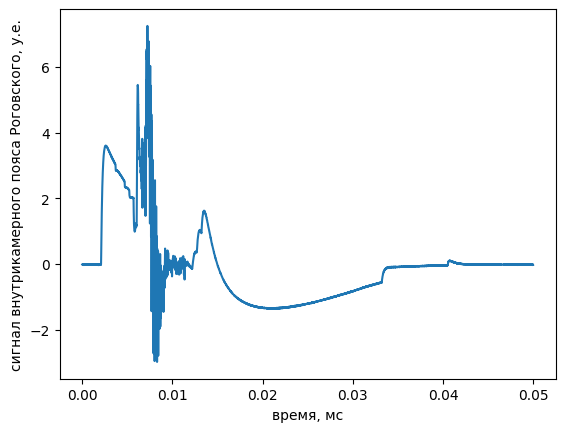

In [31]:
Time = hdf5_file['rogowski_coils']['rog_internal']['time'][:]/1000 # сразу переводим в мс
rog_CS = hdf5_file['rogowski_coils']['rog_internal']['data'][:]
plt.plot(Time, rog_CS)
plt.xlabel("время, мс")
plt.ylabel("сигнал внутрикамерного пояса Роговского, у.е.")
plt.show()